In [29]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

csv_path = 'merged_tweets.csv'
df = pd.read_csv(csv_path, dtype={'tweet_id': str}, low_memory=False)
print('Rows:', len(df))
df.head()

Rows: 376


,tweet_id,created_at,full_text,lang,is_quote,possibly_sensitive,retweet_count,favorite_count,reply_count,quote_count,...,user_desc,user_location,user_verified,is_blue_verified,followers_count,following_count,total_tweets_by_user,hashtags,urls,place
0,2001628639356711363,Thu Dec 18 12:20:30 +0000 2025,"திருப்பூர் மாவட்டம் இடுவாய் கிராமத்தில், பொதும...",ta,False,False,331,702,22,3,...,அறம் செய்ய விரும்பு. BJP Karyakartha.,India,False,True,1007659,883,18062,[],[],NaN
1,2001562955176120490,Thu Dec 18 07:59:30 +0000 2025,Thank you Erode 🙏🏻 https://t.co/897ADrZtA4,en,False,False,20139,60378,2188,1051,...,Official Page handled by Office of Actor Vijay,NaN,False,True,5519898,1,433,[],[],NaN
2,2001507639835132078,Thu Dec 18 04:19:42 +0000 2025,நடிகனுக்கு ஜால்ரா அடித்து வாங்கும் பதவி என் மய...,ta,False,False,286,1248,58,9,...,"Action Director, Actor & State President-Art a...","Chennai, India",False,True,35077,244,1852,[],[],NaN
3,2001464934690099643,Thu Dec 18 01:30:00 +0000 2025,"Hon'ble PM Thiru. @NarendraModi, Tamil Nadu is...",en,False,False,2198,3083,327,260,...,Chief Minister of Tamil Nadu | President of th...,NaN,False,True,4000735,91,11099,[],[],NaN
4,2001547505054761159,Thu Dec 18 06:58:06 +0000 2025,நாம் தமிழர் பிள்ளைகள் சேலம் மாவட்டம் தரமான சம்...,ta,False,False,415,1074,13,7,...,private,chennai,False,True,1993,2016,12502,[],[],NaN


In [30]:
# Parse datetimes, convert to IST, and compute tweet length
df['created_at'] = pd.to_datetime(df['created_at'], utc=True, errors='coerce')
# convert UTC timestamps to India timezone (Asia/Kolkata)
df['created_at_ist'] = df['created_at'].dt.tz_convert('Asia/Kolkata')
df['hour_ist'] = df['created_at_ist'].dt.hour
df['tweet_len'] = df['full_text'].astype(str).str.len()
df[['created_at','created_at_ist','hour_ist','tweet_len']].head()

/tmp/ipykernel_143734/567420714.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['created_at'] = pd.to_datetime(df['created_at'], utc=True, errors='coerce')


,created_at,created_at_ist,hour_ist,tweet_len
0,2025-12-18 12:20:30+00:00,2025-12-18 17:50:30+05:30,17,1275
1,2025-12-18 07:59:30+00:00,2025-12-18 13:29:30+05:30,13,42
2,2025-12-18 04:19:42+00:00,2025-12-18 09:49:42+05:30,9,197
3,2025-12-18 01:30:00+00:00,2025-12-18 07:00:00+05:30,7,330
4,2025-12-18 06:58:06+00:00,2025-12-18 12:28:06+05:30,12,122


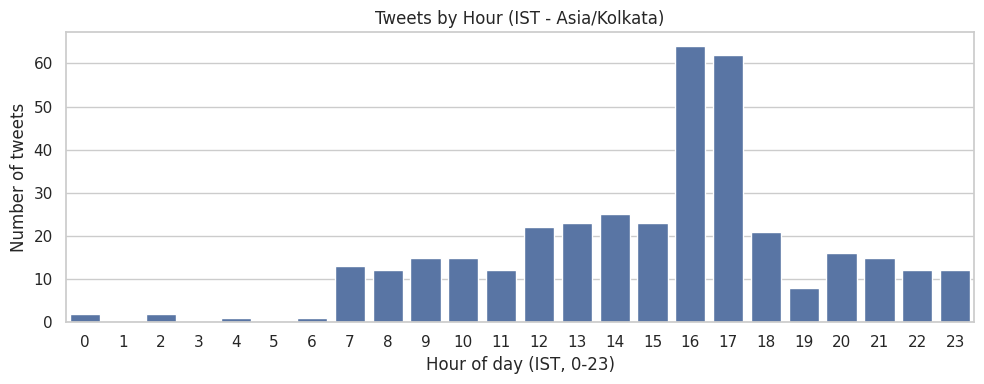

In [31]:
# Histogram of tweets by hour (converted to IST)
plt.figure(figsize=(10,4))
sns.countplot(x='hour_ist', data=df, order=list(range(24)), color='C0')
plt.title('Tweets by Hour (IST - Asia/Kolkata)')
plt.xlabel('Hour of day (IST, 0-23)')
plt.ylabel('Number of tweets')
plt.tight_layout()
plt.show()

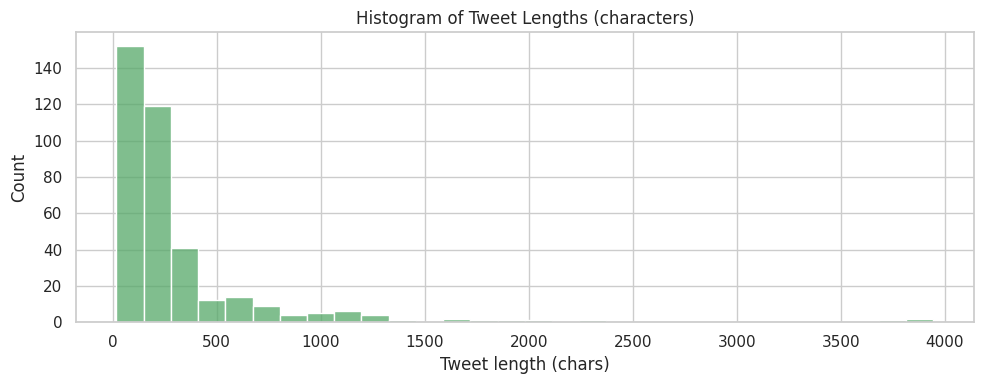

In [32]:
# Histogram of tweet lengths
plt.figure(figsize=(10,4))
sns.histplot(df['tweet_len'].dropna(), bins=30, color='C2')
plt.title('Histogram of Tweet Lengths (characters)')
plt.xlabel('Tweet length (chars)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

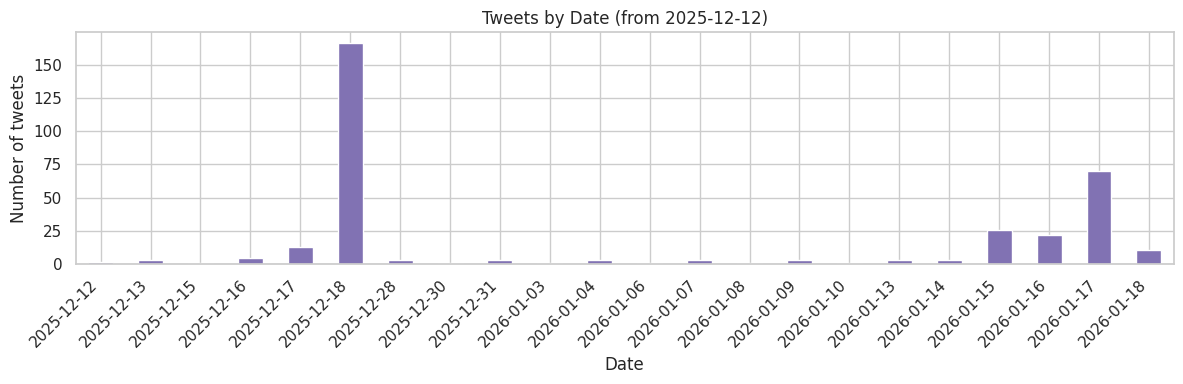

In [33]:
# Histogram of tweets by date
start = pd.to_datetime('2025-12-12', utc=True)
mask = df['created_at'].notna() & (df['created_at'] >= start)
df_from = df.loc[mask].copy()
df_from['date'] = df_from['created_at'].dt.date
counts = df_from.groupby('date').size().sort_index()
plt.figure(figsize=(12,4))
counts.plot(kind='bar', color='C4')
plt.title('Tweets by Date (from 2025-12-12)')
plt.xlabel('Date')
plt.ylabel('Number of tweets')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Political file rows: 229


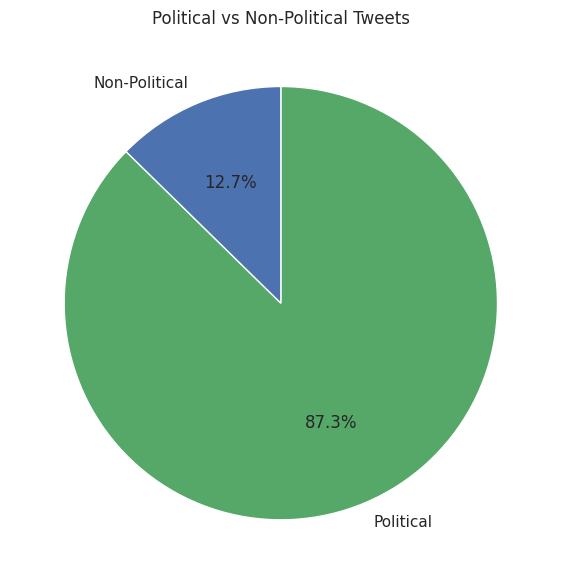

No. of political tweets: 200
No. of Non-Political tweets: 29
Total No. of Tweets: 229


In [34]:
# Load political annotation CSV and summarize
pol_path = 'data/tweet_is_political_2026-02-15.csv'
df_pol = pd.read_csv(pol_path, low_memory=False)
print('Political file rows:', len(df_pol))
df_pol.head()

# Normalize labels to Political / Non-Political
pol_label = df_pol['is_political'].astype(str).str.strip().str.lower().map(lambda x: 'Political' if x in ['yes','true','1'] else 'Non-Political')
counts = pol_label.value_counts()
total = len(pol_label)

# Pie chart for political vs non-political
plt.figure(figsize=(6,6))
counts.plot.pie(autopct='%1.1f%%', colors=['C2','C0'], startangle=90, counterclock=False)
plt.title('Political vs Non-Political Tweets')
plt.ylabel('')
plt.tight_layout()
plt.show()

# Print numeric summary
print('No. of political tweets:', int(counts.get('Political', 0)))
print('No. of Non-Political tweets:', int(counts.get('Non-Political', 0)))
print('Total No. of Tweets:', int(total))

Party-mention file rows: 1200


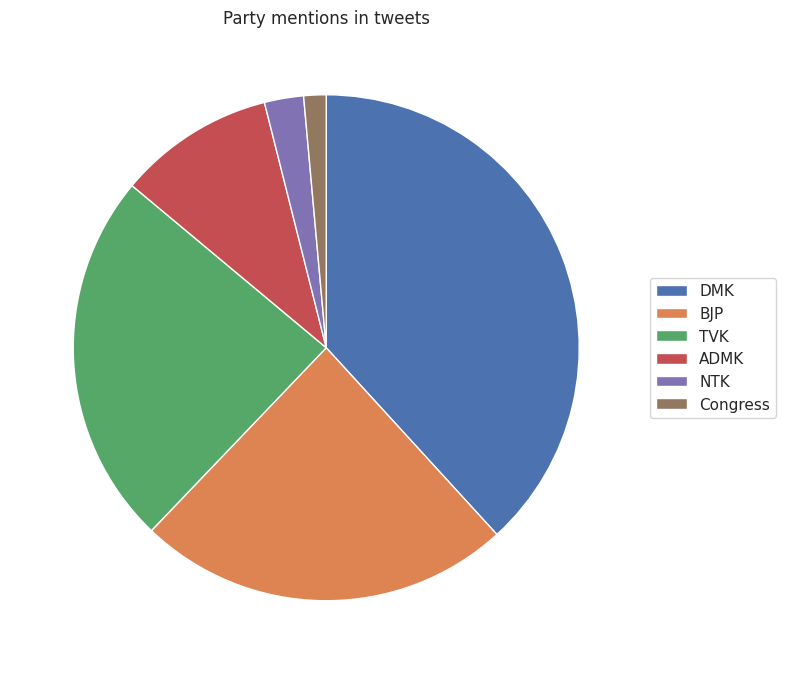

Party mention counts and percentages:
DMK: 107 (38.2%)
BJP: 67 (23.9%)
TVK: 67 (23.9%)
ADMK: 28 (10.0%)
NTK: 7 (2.5%)
Congress: 4 (1.4%)
Total party mentions: 280


In [35]:
# Load party mention CSV and summarize
party_path = 'data/tweet_party_mention_2026-02-15.csv'
df_party = pd.read_csv(party_path, low_memory=False)
print('Party-mention file rows:', len(df_party))
df_party.head()

# Ensure is_mentioned is numeric and aggregate by Party
df_party['is_mentioned'] = pd.to_numeric(df_party['is_mentioned'], errors='coerce').fillna(0).astype(int)
party_counts = df_party.groupby('Party')['is_mentioned'].sum().sort_values(ascending=False)
party_counts = party_counts[party_counts > 0]

# Pie chart of party mentions 
plt.figure(figsize=(8,8))
wedges, texts = plt.pie(party_counts, startangle=90, counterclock=False)
plt.title('Party mentions in tweets')
plt.ylabel('')
plt.legend(labels=party_counts.index.tolist(), loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.show()

# Print counts and percentages as text output
total = int(party_counts.sum())
print('Party mention counts and percentages:')
for party, cnt in party_counts.items():
    pct = cnt / total * 100 if total > 0 else 0.0
    print(f'{party}: {int(cnt)} ({pct:.1f}%)')
print('Total party mentions:', total)